In [1]:
# Load environment variables and set up auto-reload
import os
from dotenv import load_dotenv

load_dotenv()

# Remove LangSmith env vars so tracing goes only to Langfuse
from utils import disable_langsmith
disable_langsmith()

# Align certificate settings for requests-based clients (Tavily, etc.)
# Skip when DISABLE_SSL_VERIFY is active — utils.py handles SSL bypass globally.
if os.getenv("DISABLE_SSL_VERIFY", "").lower() not in ("1", "true", "yes"):
    if os.getenv("SSL_CERT_FILE") and not os.getenv("REQUESTS_CA_BUNDLE"):
        os.environ["REQUESTS_CA_BUNDLE"] = os.environ["SSL_CERT_FILE"]
    if os.getenv("SSL_CERT_FILE") and not os.getenv("CURL_CA_BUNDLE"):
        os.environ["CURL_CA_BUNDLE"] = os.environ["SSL_CERT_FILE"]

%load_ext autoreload
%autoreload 2


# Research Supervisor

*The supervisor has a simple job: delegate research tasks to an appropriate number of sub-agents.*

Here is our overall research flow:

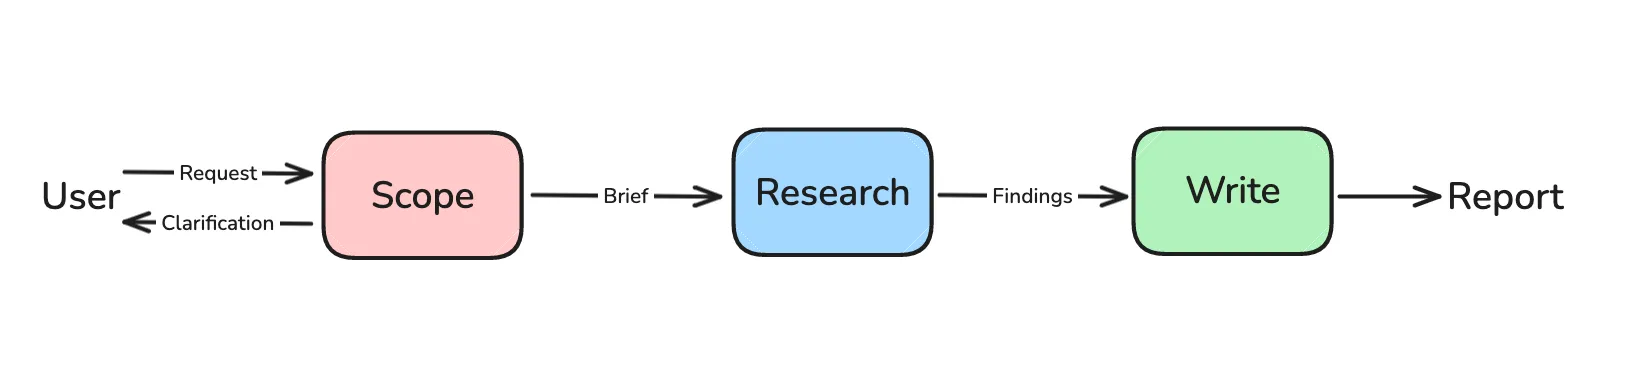

We previously built a research agent bound to either custom tools or MCP server. Now, what happens if the request is complex and has several sub-topics? Single agent response quality *can* suffer with multiple sub-topics (e.g., compare A to B to C) because a single context window needs to store and reason about tool feedback across all of the sub-topics. 

[Numerous failure modes](https://www.dbreunig.com/2025/06/22/how-contexts-fail-and-how-to-fix-them.html), such as [context clash](https://www.dbreunig.com/2025/06/22/how-contexts-fail-and-how-to-fix-them.html), become prevalent as the context window accumulates tool calls across many different sub-topics. As discussed in [Anthropic's blog post](https://www.anthropic.com/engineering/built-multi-agent-research-system), multi-agent systems can split sub-topic to sub-agents with isolated context windows. We'll build a system where a supervisor determines if the research brief can be broken-down into independent sub-topics and delegates to sub-agents with isolated context windows. 

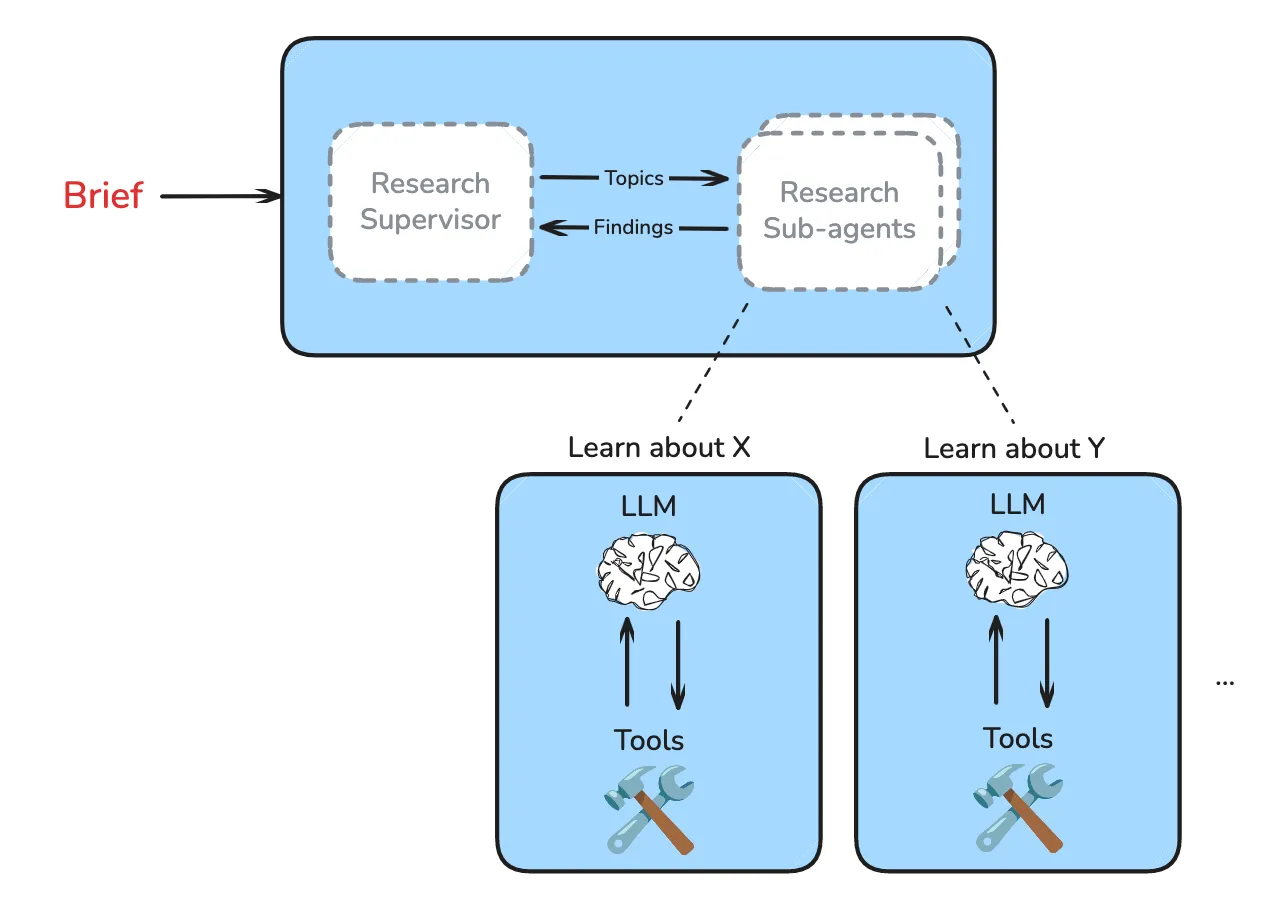

### Prompt

Now, let's design a prompt for the supervisor that follows the principles we've discussed, and include some insights from [the research literature](https://www.anthropic.com/engineering/built-multi-agent-research-system).

#### 1. Think Like The Agent
What instructions would you give a new work colleague?
- **Read the question carefully** - What specific information does the user need?
- **Decide how to delegate the research** - Carefully consider the question and decide how to delegate the research. Are there multiple independent directions that can be explored simultaneously?
- **After each call to ConductResearch, pause and assess** - Do I have enough to answer? What's still missing?

#### 2. Concrete Heuristics (For task delegation)
Use **Hard Limits** to prevent the research agent from calling tools excessively:
- **Bias towards single agent** - Use single agent for simplicity unless the user request has clear opportunity for parallelization. 
- **Stop when you can answer confidently** - Don't keep delegating research for perfection.
- **Limit tool calls** - Always stop after 3 tool calls to ConductResearch if you cannot find the right source(s).

#### 3. Show your thinking
Before you call ConductResearch tool call, use think_tool to plan your approach:
- Can the task be broken down into smaller sub-tasks?

After each ConductResearch tool call, use think_tool to analyze the results:
- What key information did I find? 
- What's missing?
- Do I have enough to answer the question comprehensively?
- Should I search more or provide my answer?

#### 4. Scaling rules
Simple fact-finding, lists, and rankings can use a single sub-agent.
- *Example*: List the top 10 coffee shops in San Francisco -> Use 1 sub-agent

Comparisons presented in the user request can use a sub-agent for each element of the comparison.
- *Example*: Compare OpenAI vs. Anthropic vs. DeepMind approaches to AI safety -> Use 3 sub-agents.
- Delegate clear, distinct, non-overlapping subtopics

In [2]:
from utils import show_prompt
from deep_research_from_scratch.prompts import lead_researcher_prompt
show_prompt(lead_researcher_prompt, "Lead Researcher Prompt")

╭──────────────────────────────────────────── Lead Researcher Prompt ─────────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research supervisor. Your job is to conduct research by calling the "ConductResearch" tool. For      │
│  context, today's date is {date}.                                                                               │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your focus is to call the "ConductResearch" tool to conduct research against the overall research question     │
│  passed in by the user.                                                                                         │
│  When you are completely satisfied with the research findings returned from the tool calls, then you should     │
│  call the "ResearchComplete" tool to indicate that you are done with your research.                             │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  You have access to three main tools:                                                                           │
│  1. **ConductResearch**: Delegate research tasks to specialized sub-agents                                      │
│  2. **ResearchComplete**: Indicate that research is complete                                                    │
│  3. **think_tool**: For reflection and strategic planning during research                                       │
│                                                                                                                 │
│  **CRITICAL: Use think_tool before calling ConductResearch to plan your approach, and after each                │
│  ConductResearch to assess progress**                                                                           │
│  **PARALLEL RESEARCH**: When you identify multiple independent sub-topics that can be explored simultaneously,  │
│  make multiple ConductResearch tool calls in a single response to enable parallel research execution. This is   │
│  more efficient than sequential research for comparative or multi-faceted questions. Use at most                │
│  {max_concurrent_research_units} parallel agents per iteration.                                                 │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a research manager with limited time and resources. Follow these steps:                             │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Decide how to delegate the research** - Carefully consider the question and decide how to delegate the    │
│  research. Are there multiple independent directions that can be explored simultaneously?                       │
│  3. **After each call to ConductResearch, pause and assess** - Do I have enough to answer? What's still         │
│  missing?                                                                                                       │
│  </Instructions>                                      

### State

The supervisor state manages the overall research coordination, while the researcher state handles individual research tasks.

In [3]:
%%writefile ../src/deep_research_from_scratch/state_multi_agent_supervisor.py

"""State Definitions for Multi-Agent Research Supervisor.

This module defines the state objects and tools used for the multi-agent
research supervisor workflow, including coordination state and research tools.
"""

import operator

from langchain_core.messages import BaseMessage
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from typing_extensions import Annotated, Sequence, TypedDict

from deep_research_from_scratch.state_research import ImageResult


class SupervisorState(TypedDict):
    """State for the multi-agent research supervisor.

    Manages coordination between supervisor and research agents, tracking
    research progress and accumulating findings from multiple sub-agents.
    """

    # Messages exchanged with supervisor for coordination and decision-making
    supervisor_messages: Annotated[Sequence[BaseMessage], add_messages]
    # Detailed research brief that guides the overall research direction
    research_brief: str
    # Processed and structured notes ready for final report generation
    notes: Annotated[list[str], operator.add] = []
    # Counter tracking the number of research iterations performed
    research_iterations: int = 0
    # Raw unprocessed research notes collected from sub-agent research
    raw_notes: Annotated[list[str], operator.add] = []
    # Collected image metadata from sub-agent research
    images: Annotated[list[ImageResult], operator.add] = []

@tool
class ConductResearch(BaseModel):
    """Tool for delegating a research task to a specialized sub-agent."""
    research_topic: str = Field(
        description="The topic to research. Should be a single topic, and should be described in high detail (at least a paragraph).",
    )

@tool
class ResearchComplete(BaseModel):
    """Tool for indicating that the research process is complete."""
    pass


Overwriting ../src/deep_research_from_scratch/state_multi_agent_supervisor.py


### Multi-agent 

Now, we'll define our agent. A multi-agent system is a system that consists of multiple agents that work together to complete a task. The main benefit is context isolated, as discussed in [Context Engineering for Agents](https://blog.langchain.com/context-engineering-for-agents/). 

In [4]:
%%writefile ../src/deep_research_from_scratch/multi_agent_supervisor.py

"""Multi-agent supervisor for coordinating research across multiple specialized agents.

This module implements a supervisor pattern where:
1. A supervisor agent coordinates research activities and delegates tasks
2. Multiple researcher agents work on specific sub-topics independently
3. Results are aggregated and compressed for final reporting

The supervisor uses parallel research execution to improve efficiency while
maintaining isolated context windows for each research topic.
"""

import asyncio
import os

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
    filter_messages,
)
from langchain_core.runnables import RunnableConfig
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command
from typing_extensions import Literal

from deep_research_from_scratch.Helper import GenAIToken
from deep_research_from_scratch.prompts import lead_researcher_prompt
from deep_research_from_scratch.research_agent import researcher_agent
from deep_research_from_scratch.state_multi_agent_supervisor import (
    ConductResearch,
    ResearchComplete,
    SupervisorState,
)
from deep_research_from_scratch.state_research import ImageResult
from deep_research_from_scratch.trend_dimensions import (
    format_dimensions_for_prompt,
    load_trend_dimensions,
)
from deep_research_from_scratch.utils import get_today_str, normalize_model_id, think_tool

load_dotenv()


def get_notes_from_tool_calls(messages: list[BaseMessage]) -> list[str]:
    """Extract research notes from ToolMessage objects in supervisor message history.

    This function retrieves the compressed research findings that sub-agents
    return as ToolMessage content. When the supervisor delegates research to
    sub-agents via ConductResearch tool calls, each sub-agent returns its
    compressed findings as the content of a ToolMessage. This function
    extracts all such ToolMessage content to compile the final research notes.

    Args:
        messages: List of messages from supervisor's conversation history

    Returns:
        List of research note strings extracted from ToolMessage objects
    """
    return [tool_msg.content for tool_msg in filter_messages(messages, include_types="tool")]


# Ensure async compatibility for Jupyter environments
try:
    import nest_asyncio
    try:
        from IPython import get_ipython
        if get_ipython() is not None:
            nest_asyncio.apply()
    except ImportError:
        pass
except ImportError:
    pass


# ===== CONFIGURATION =====

_DEFAULT_SUPERVISOR_MODEL = "azure_openai:gpt-5.3"

# Tool list for the supervisor (distinct name avoids collision with the node function below)
SUPERVISOR_TOOLSET = [ConductResearch, ResearchComplete, think_tool]

# Maximum number of tool call iterations for individual researcher agents
max_researcher_iterations = 6

# Maximum number of concurrent research agents the supervisor can launch
max_concurrent_researchers = 3


def _build_model(model_id: str, **kwargs):
    """Build an Azure OpenAI model instance from a model identifier string.

    Extracts the deployment name from the model identifier using the
    convention that model name equals deployment name (e.g.,
    "azure_openai:gpt-5.3" -> deployment "GPT-5.3").
    """
    normalized_model_id = normalize_model_id(model_id)
    deployment = normalized_model_id.split(":")[-1]
    return init_chat_model(
        model=normalized_model_id,
        azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
        azure_deployment=deployment,
        api_key=GenAIToken().token(),
        api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
        default_headers={
            "project-name": os.getenv("HEADERS_PROJECT_NAME"),
            "userid": os.getenv("HEADERS_USERID"),
        },
        **kwargs,
    )


# ===== SUPERVISOR NODES =====

def _build_supervisor_dimensions_section() -> str:
    """Build the expert dimensions section for the supervisor prompt.

    Returns a full XML section string when dimensions are available,
    or an empty string for graceful degradation (no empty XML block).
    """
    dims = format_dimensions_for_prompt(load_trend_dimensions())
    if not dims:
        return ""
    return (
        "<Expert Dimensions>\n"
        "When decomposing the research question into parallel sub-tasks, consider "
        "structuring ConductResearch calls around these expert analytical dimensions:\n"
        f"{dims}\n"
        "Adapt them to the research question — not all dimensions apply to every topic. "
        "Do not create more sub-tasks than your concurrency limit allows.\n"
        "</Expert Dimensions>\n"
    )


async def supervisor(state: SupervisorState, config: RunnableConfig) -> Command[Literal["supervisor_tools"]]:
    """Coordinate research activities.

    Analyzes the research brief and current progress to decide:
    - What research topics need investigation
    - Whether to conduct parallel research
    - When research is complete

    Model is controlled by config["configurable"]["supervisor_model"]
    (default: "azure_openai:gpt-5.3").

    Args:
        state: Current supervisor state with messages and research progress
        config: LangGraph runtime config; supports configurable["supervisor_model"]

    Returns:
        Command to proceed to supervisor_tools node with updated state
    """
    configurable = config.get("configurable", {})
    supervisor_model = _build_model(
        configurable.get("supervisor_model", _DEFAULT_SUPERVISOR_MODEL),
        temperature=1.0,
    )
    supervisor_model_with_tools = supervisor_model.bind_tools(SUPERVISOR_TOOLSET)

    supervisor_messages = state.get("supervisor_messages", [])

    trend_dims = _build_supervisor_dimensions_section()
    system_message = lead_researcher_prompt.format(
        date=get_today_str(),
        max_concurrent_research_units=max_concurrent_researchers,
        max_researcher_iterations=max_researcher_iterations,
        trend_dimensions=trend_dims
    )
    messages = [SystemMessage(content=system_message)] + supervisor_messages

    response = await supervisor_model_with_tools.ainvoke(messages)

    return Command(
        goto="supervisor_tools",
        update={
            "supervisor_messages": [response],
            "research_iterations": state.get("research_iterations", 0) + 1
        }
    )


async def supervisor_tools(state: SupervisorState, config: RunnableConfig) -> Command[Literal["supervisor", "__end__"]]:
    """Execute supervisor decisions - either conduct research or end the process.

    Handles:
    - Executing think_tool calls for strategic reflection
    - Launching parallel research agents for different topics
    - Aggregating research results
    - Determining when research is complete

    Propagates the runtime config to each researcher sub-agent so that
    configurable model overrides (e.g. research_model, compress_model) apply
    throughout the full pipeline.

    Args:
        state: Current supervisor state with messages and iteration count
        config: LangGraph runtime config forwarded to researcher sub-agents

    Returns:
        Command to continue supervision, end process, or handle errors
    """
    supervisor_messages = state.get("supervisor_messages", [])
    research_iterations = state.get("research_iterations", 0)
    most_recent_message = supervisor_messages[-1]

    tool_messages = []
    all_raw_notes = []
    all_images: list[ImageResult] = []
    next_step = "supervisor"
    should_end = False

    exceeded_iterations = research_iterations >= max_researcher_iterations
    no_tool_calls = not most_recent_message.tool_calls
    research_complete = any(
        tool_call["name"] == "ResearchComplete"
        for tool_call in most_recent_message.tool_calls
    )

    if exceeded_iterations or no_tool_calls or research_complete:
        should_end = True
        next_step = END

    else:
        try:
            think_tool_calls = [
                tool_call for tool_call in most_recent_message.tool_calls
                if tool_call["name"] == "think_tool"
            ]

            conduct_research_calls = [
                tool_call for tool_call in most_recent_message.tool_calls
                if tool_call["name"] == "ConductResearch"
            ]

            for tool_call in think_tool_calls:
                observation = think_tool.invoke(tool_call["args"])
                tool_messages.append(
                    ToolMessage(
                        content=observation,
                        name=tool_call["name"],
                        tool_call_id=tool_call["id"]
                    )
                )

            if conduct_research_calls:
                # Pass config explicitly so researcher sub-agents inherit configurable overrides
                coros = [
                    researcher_agent.ainvoke(
                        {
                            "researcher_messages": [
                                HumanMessage(content=tool_call["args"]["research_topic"])
                            ],
                            "research_topic": tool_call["args"]["research_topic"]
                        },
                        config=config,
                    )
                    for tool_call in conduct_research_calls
                ]

                tool_results = await asyncio.gather(*coros)

                research_tool_messages = [
                    ToolMessage(
                        content=result.get("compressed_research", "Error synthesizing research report"),
                        name=tool_call["name"],
                        tool_call_id=tool_call["id"]
                    ) for result, tool_call in zip(tool_results, conduct_research_calls)
                ]

                tool_messages.extend(research_tool_messages)

                all_raw_notes = [
                    "\n".join(result.get("raw_notes", []))
                    for result in tool_results
                ]

                # Aggregate images from sub-agents with URL dedup
                seen_urls = {
                    img.url for img in state.get("images", [])
                }
                for result in tool_results:
                    for img in result.get("images", []):
                        if img.url not in seen_urls:
                            seen_urls.add(img.url)
                            all_images.append(img)

        except Exception as e:
            print(f"Error in supervisor tools: {e}")  # noqa: T201
            should_end = True
            next_step = END

    if should_end:
        return Command(
            goto=next_step,
            update={
                "notes": get_notes_from_tool_calls(supervisor_messages),
                "research_brief": state.get("research_brief", "")
            }
        )
    else:
        return Command(
            goto=next_step,
            update={
                "supervisor_messages": tool_messages,
                "raw_notes": all_raw_notes,
                "images": all_images,
            }
        )


# ===== GRAPH CONSTRUCTION =====

supervisor_builder = StateGraph(SupervisorState)
supervisor_builder.add_node("supervisor", supervisor)
supervisor_builder.add_node("supervisor_tools", supervisor_tools)
supervisor_builder.add_edge(START, "supervisor")
supervisor_agent = supervisor_builder.compile()


Overwriting ../src/deep_research_from_scratch/multi_agent_supervisor.py


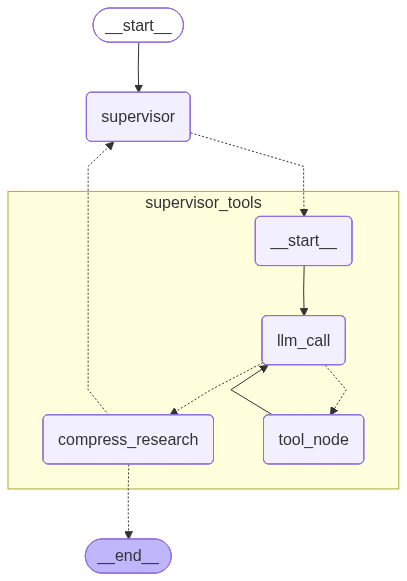

In [2]:
import base64
import httpx
from IPython.display import Image, display
from deep_research_from_scratch.multi_agent_supervisor import supervisor_agent

# Show the agent
mermaid = supervisor_agent.get_graph(xray=True).draw_mermaid()
encoded = base64.urlsafe_b64encode(mermaid.encode("utf-8")).decode("ascii")
image_url = f"https://mermaid.ink/img/{encoded}?type=png&bgColor=%21white"

with httpx.Client(timeout=20.0, verify=False, trust_env=True) as client:
    response = client.get(image_url)
    response.raise_for_status()
    png_bytes = response.content

display(Image(png_bytes))

In [3]:
# Run the multi-agent supervisor agent
import os
import uuid
from utils import format_messages, init_langfuse_tracing
from langchain_core.messages import HumanMessage

research_brief = """请研究近半年来（以今天 May 6, 2026 为基准，约过去 6                                                           
个月）中国市场高端面部精华与面霜中“内容物本身”的液体/膏体设计元素趋势，明确排除外包装、瓶器、盒身、标签、泵头等包装
设计因素。我希望重点分析产品内容物在视觉与感官层面的趋势，包括：颜色（如透明、半透明、乳白、珠光、金属感、渐变感等 
）、装饰（如金箔/银箔、胶囊珠、悬浮颗粒、微气泡、花瓣/植物碎片、闪片等可见添加物或视觉点缀）、纹理感（如水感、凝胶 
感、丝绒感、奶霜感、啫喱感、拉丝感、厚薄度、流动性、包裹感等）。请优先使用中文来源，并尽量链接到品牌官方页面、品牌 
官方社媒/视频号/小红书/天猫旗舰店/京东旗舰店、权威美妆零售平台、行业媒体或可直接看到产品内容物实拍/演示的原始来源，
而不是二手汇总博客。请在研究中附上可参考图片或可直接查看图片/视频的原始链接，图片应尽量展示内容物本身而非包装。    

请按以下维度拆解趋势研究：                                                                                         

 1 [Geographic Market]                                                                                             
   在中国市场，近半年来高端面部精华/面霜内容物设计出现了哪些主流与新兴趋势？请限定在中国消费者可购买、且在中国市场 
   有传播与上新动作的高端品牌/产品，必要时区分国际品牌在中国与本土高端品牌的表现差异。                             
 2 [Product Category + Product Format]                                                                             
   面部精华与面霜这两个子品类中，内容物设计元素分别呈现出哪些不同趋势？请区分精华、乳霜，以及必要时纳入相关近邻质地
   （如精华凝胶、乳液霜、睡眠面膜式面霜）作为开放考虑，但不要偏离“面部精华/面霜”主范围。                           
 3 [Aesthetic Direction + Sensory Experience]                                                                      
   从颜色、装饰、纹理感三个核心维度出发，当前高端产品内容物的审美方向与感官体验趋势是什么？请总结高频视觉代码、触感
   联想、仪式感表达，以及这些设计如何服务于“高端感”“功效感”或“愉悦感”的传达。                                      
 4 [Claims and Evidence + Ingredient Strategy]                                                                     
   这些内容物设计元素通常如何与功效诉求、成分故事或科技话术绑定？请分析例如修护、抗老、焕亮、舒缓、屏障、奢养等常见
   高端护肤诉求，如何通过颜色、可见颗粒、珠光、胶囊化、悬浮体系、特殊纹理等被视觉化表达；若某些设计更多是审美/营销 
   导向而非功效必要，也请明确指出。                                                                                
 5 [Channel and Touchpoint + Trend Momentum]                                                                       
   哪些渠道最能观察到这些趋势的形成与扩散（如品牌官方图、上脸演示视频、达人测评、小红书、抖音、天猫详情页、专柜展示
   等）？请判断各类内容物设计趋势在近半年来是“新兴信号、加速增长、已趋主流还是热度回落”，并尽量给出可支持判断的上新
   案例、传播热度或重复出现信号。                                                                                  
 6 [Business Impact + Value Positioning]                                                                           
   从高端定位角度看，这些内容物设计趋势对品牌的商业与产品策略意味着什么？请分析哪些液体/膏体设计元素更常见于高端价 
   位带，哪些可能成为同质化风险，哪些可能构成未来的差异化机会。若价格带边界未被用户明确定义，请将“高端”作为中国护肤
   市场中的 premium/luxury 语境处理，并在研究中说明所采用的判断标准。                                              

输出时请尽量给出：代表性趋势清单、每个趋势对应的具体品牌/产品案例、可查看内容物的图片或视频链接、以及简要说明该案例
为何能代表该趋势。若某些图片仅能通过电商详情页、官方社媒帖子或视频截图观察，请明确标注来源与可见内容物的程度。"""

thread_id = str(uuid.uuid4())
trace_tag = f"nb4-supervisor-{thread_id[:8]}"
langfuse_handler = init_langfuse_tracing()

config = {
    "configurable": {"thread_id": thread_id},
    "callbacks": [langfuse_handler],
    "tags": [trace_tag],
    "metadata": {
        "thread_id": thread_id,
        "notebook": "4_research_supervisor",
        "langfuse_session_id": thread_id,
        "langfuse_tags": [trace_tag],
    },
    "scope_model":         "azure_openai:GPT-54-2026-03-05",
    "research_model":      "azure_openai:GPT-54-2026-03-05",
    "summarization_model": "azure_openai:GPT-54-2026-03-05",
    "compress_model":      "azure_openai:GPT-54-2026-03-05",
    "supervisor_model":    "azure_openai:GPT-54-2026-03-05",
    "writer_model":        "azure_openai:GPT-54-2026-03-05",
}

result = await supervisor_agent.ainvoke(
  {
    "supervisor_messages": [HumanMessage(content=research_brief)],
    "research_brief": research_brief,
    "notes": [],
    "research_iterations": 0,
    "raw_notes": [],
    "images": [],
  },
  config=config,
)
format_messages(result["supervisor_messages"])


Error in supervisor tools: HTTPSConnectionPool(host='api.tavily.com', port=443): Max retries exceeded with url: /search (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1000)')))


╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ 请研究近半年来（以今天 May 6, 2026 为基准，约过去 6                                                             │
│ 个月）中国市场高端面部精华与面霜中“内容物本身”的液体/膏体设计元素趋势，明确排除外包装、瓶器、盒身、标签、泵头等 │
│ 包装                                                                                                            │
│ 设计因素。我希望重点分析产品内容物在视觉与感官层面的趋势，包括：颜色（如透明、半透明、乳白、珠光、金属感、渐变  │
│ 感等                                                                                                            │
│ ）、装饰（如金箔/银箔、胶囊珠、悬浮颗粒、微气泡、花瓣/植物碎片、闪片等可见添加物或视觉点缀）、纹理感（如水感、  │
│ 凝胶                                                                                                            │
│ 感、丝绒感、奶霜感、啫喱感、拉丝感、厚薄度、流动性、包裹感等）。请优先使用中文来源，并尽量链接到品牌官方页面、  │
│ 品牌                                                                                                            │
│ 官方社媒/视频号/小红书/天猫旗舰店/京东旗舰店、权威美妆零售平台、行业媒体或可直接看到产品内容物实拍/演示的原始来 │
│ 源，                                                                                                            │
│ 而不是二手汇总博客。请在研究中附上可参考图片或可直接查看图片/视频的原始链接，图片应尽量展示内容物本身而非包装。 │
│                                                                                                                 │
│ 请按以下维度拆解趋势研究：                                                                                      │
│                                                                                                                 │
│  1 [Geographic Market]                                                                                          │
│    在中国市场，近半年来高端面部精华/面霜内容物设计出现了哪些主流与新兴趋势？请限定在中国消费者可购买、且在中国  │
│ 市场                                                                                                            │
│    有传播与上新动作的高端品牌/产品，必要时区分国际品牌在中国与本土高端品牌的表现差异。                          │
│  2 [Product Category + Product Format]                                                                          │
│    面部精华与面霜这两个子品类中，内容物设计元素分别呈现出哪些不同趋势？请区分精华、乳霜，以及必要时纳入相关近邻 │
│ 质地                                                                                                            │
│    （如精华凝胶、乳液霜、睡眠面膜式面霜）作为开放考虑，但不要偏离“面部精华/面霜”主范围。                        │
│  3 [Aesthetic Direction + Sensory Experience]                                                                   │
│    从颜色、装饰、纹理感三个核心维度出发，当前高端产品内容物的审美方向与感官体验趋势是什么？请总结高频视觉代码、 │
│ 触感                                                                                                            │
│    联想、仪式感表达，以及这些设计如何服务于“高端感”“功效感”或“愉悦感”的传达。                                   │
│  4 [Claims and Evidence + Ingredient Strategy]                                                                  │
│    这些内容物设计元素通常如何与功效诉求、成分故事或科技话术绑定？请分析例如修护、抗老、焕亮、舒缓、屏障、奢养等 │
│ 常见                                                                                                            │
│    高端护肤诉求，如何通过颜色、可见颗粒、珠光、胶囊化、悬浮体系、特殊纹理等被视觉化表达；若某些设计更多是审美/  │
│ 营销                                                                                                            │
│    导向而非功效必要，也请明确指出。                                                                             │
│  5 [Channel and Touchpoint + Trend Momentum]                                                                    │
│    哪些渠道最能观察到这些趋势的形成与扩散（如品牌官方图、上脸演示视频、达人测评、小红书、抖音、天猫详情页、专柜 │
│ 展示                                                                                                            │
│    等）？请判断各类内容物设计趋势在近半年来是“新兴信号、加速增长、已趋主流还是热度回落”，并尽量给出可支持判断的 │
│ 上新                                                                                                            │
│    案例、传播热度或重复出现信号。                                                                               │
│  6 [Business Impact + Value Positioning]                                                                        │
│    从高端定位角度看，这些内容物设计趋势对品牌的商业与产品策略意味着什么？请分析哪些液体/膏体设计元素更常见于高  │
│ 端价                                                                                 

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection":                                                                                                 │
│ "\u7528\u6237\u95ee\u9898\u590d\u6742\uff0c\u9002\u5408\u5206\u6210\u6700\u591a3\u4e2a\u5e76\u884c\u5b50\u9898\ │
│ uff1a1\uff09\u4e2d\u56fd\u5e02\u573a\u8fd16\u4e2a\u6708\u9ad8\u7aef\u9762\u90e8\u7cbe\u534e\u7684\u5185\u5bb9\u │
│ 7269\u8bbe\u8ba1\u8d8b\u52bf\u4e0e\u6848\u4f8b\uff1b2\uff09\u4e2d\u56fd\u5e02\u573a\u8fd16\u4e2a\u6708\u9ad8\u7 │
│ aef\u9762\u971c\u53ca\u8fd1\u90bb\u971c\u72b6\u4ea7\u54c1\u7684\u5185\u5bb9\u7269\u8bbe\u8ba1\u8d8b\u52bf\u4e0e │
│ \u6848\u4f8b\uff1b3\uff09\u6e20\u9053\u4f20\u64ad\u3001\u8d8b\u52bf\u52a8\u91cf\u3001\u5546\u4e1a\u542b\u4e49\u │
│ 4e0e\u529f\u6548/\u6210\u5206\u7ed1\u5b9a\u65b9\u5f0f\u3002\u6240\u6709\u5b50\u4efb\u52a1\u90fd\u8981\u4f18\u51 │
│ 48\u4e2d\u6587\u6765\u6e90\uff0c\u4e14\u8981\u5c3d\u91cf\u7ed9\u51fa\u54c1\u724c\u5b98\u65b9\u3001\u7535\u5546\ │
│ u65d7\u8230\u5e97\u3001\u5c0f\u7ea2\u4e66\u3001\u89c6\u9891\u53f7\u3001\u6743\u5a01\u96f6\u552e\u6216\u884c\u4e │
│ 1a\u5a92\u4f53\u4e2d\u7684\u539f\u59cb\u56fe\u7247/\u89c6\u9891\u94fe\u63a5\uff0c\u91cd\u70b9\u770b\u5185\u5bb9 │
│ \u7269\u672c\u8eab\uff0c\u4e0d\u770b\u5305\u88c5\u3002\u9700\u8981\u9650\u5b9a\u5230\u4e2d\u56fd\u5e02\u573a\u5 │
│ 3ef\u8d2d\u4e70\u4e14\u8fd1\u534a\u5e74\u6709\u4f20\u64ad/\u4e0a\u65b0\u52a8\u4f5c\u7684\u9ad8\u7aef\u54c1\u724 │
│ c\u3002\u5148\u5e76\u884c\u641c\u96c6\u4e09\u8def\u4fe1\u606f\uff0c\u7136\u540e\u518d\u5224\u65ad\u662f\u5426\u │
│ 9700\u8981\u8865\u5145\u3002"                                                                                   │
│ }                                                                                                               │
│    ID: call_dQVZOntEgAjRzCakapYlux7F                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded:                                                                                            │
│ 用户问题复杂，适合分成最多3个并行子题：1）中国市场近6个月高端面部精华的内容物设计趋势与案例；2）中国市场近6个月 │
│ 高端面霜及近邻霜状产品的内容物设计趋势与案例；3）渠道传播、趋势动量、商业含义与功效/成分绑定方式。所有子任务都  │
│ 要优先中文来源，且要尽量给出品牌官方、电商旗舰店、小红书、视频号、权威零售或行业媒体中的原始图片/视频链接，重点 │
│ 看内容物本身，不看包装。需要限定到中国市场可购买且近半年有传播/上新动作的高端品牌。先并行搜集三路信息，然后再判 │
│ 断是否需要补充。                                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: ConductResearch                                                                                   │
│    Args: {                                                                                                      │
│   "research_topic":                                                                                             │
│ "\u7814\u7a76\u8fd1\u534a\u5e74\u6765\uff08\u4ee52026\u5e745\u67086\u65e5\u4e3a\u57fa\u51c6\uff0c\u7ea6\u8fc7\u │
│ 53bb6\u4e2a\u6708\uff09\u4e2d\u56fd\u5e02\u573a\u53ef\u8d2d\u4e70\u4e14\u6709\u4f20\u64ad/\u4e0a\u65b0\u52a8\u4 │
│ f5c\u7684\u9ad8\u7aef\u9762\u90e8\u7cbe\u534e\u4ea7\u54c1\uff0c\u5728\u201c\u5185\u5bb9\u7269\u672c\u8eab\u201d │
│ \u7684\u6db2\u4f53\u8bbe\u8ba1\u5143\u7d20\u4e0a\u7684\u8d8b\u52bf\u3002\u660e\u786e\u6392\u9664\u5916\u5305\u8 │
│ 8c5\u3001\u74f6\u5668\u3001\u76d2\u8eab\u3001\u6807\u7b7e\u3001\u6cf5\u5934\u7b49\u5305\u88c5\u8bbe\u8ba1\u3002 │
│ \u91cd\u70b9\u68b3\u7406\u989c\u8272\uff08\u900f\u660e\u3001\u534a\u900f\u660e\u3001\u4e73\u767d\u3001\u73e0\u5 │
│ 149\u3001\u91d1\u5c5e\u611f\u3001\u6e10\u53d8\u611f\u7b49\uff09\u3001\u88c5\u9970\uff08\u80f6\u56ca\u73e0\u3001 │
│ \u60ac\u6d6e\u9897\u7c92\u3001\u5fae\u6c14\u6ce1\u3001\u82b1\u74e3/\u690d\u7269\u788e\u7247\u3001\u95ea\u7247\u │
│ 7b49\u53ef\u89c1\u6dfb\u52a0\u7269\u6216\u89c6\u89c9\u70b9\u7f00\uff09\u3001\u7eb9\u7406\u611f\uff08\u6c34\u611 │
│ f\u3001\u51dd\u80f6\u611f\u3001\u556b\u55b1\u611f\u3001\u62c9\u4e1d\u611f\u3001\u539a\u8584\u5ea6\u3001\u6d41\u │
│ 52a8\u6027\u3001\u5305\u88f9\u611f\u7b49\uff09\u5728\u9ad8\u7aef\u7cbe\u534e\u4e2d\u7684\u4e3b\u6d41\u4e0e\u65b │
│ 0\u5174\u8d8b\u52bf\u3002\u8bf7\u4f18\u5148\u4f7f\u7528\u4e2d\u6587\u6765\u6e90\uff0c\u5c3d\u91cf\u94fe\u63a5\u │
│ 5230\u54c1\u724c\u5b98\u65b9\u9875\u9762\u3001\u54c1\u724c\u5b98\u65b9\u5c0f\u7ea2\u4e66/\u89c6\u9891\u53f7/\u6 │
│ 296\u97f3\u3001\u5929\u732b\u65d7\u8230\u5e97\u3001\u4eac\u4e1c\u65d7\u8230\u5e97\u3001\u4e1d\u8299\u5170\u4e2d │
│ \u56fd\u3001\u5b98\u65b9\u65b0\u95fb\u7a3f\u6216\u6743\u5a01\u884c\u4e1a\u5a92\u4f53\uff0c\u5e76\u63d0\u4f9b\u5 │
│ 3ef\u76f4\u63a5\u67e5\u770b\u4ea7\u54c1\u5185\u5bb9\u7269\u5b9e\u62cd\u6216\u6f14\u793a\u7684\u539f\u59cb\u56fe │
│ \u7247/\u89c6\u9891\u94fe\u63a5\u3002\u8bf7\u8f93\u51fa\uff1a1\uff09\u4ee3\u8868\u6027\u8d8b\u52bf\u6e05\u5355\ │
│ uff1b2\uff09\u6bcf\u4e2a\u8d8b\u52bf\u5bf9\u5e94\u7684\u4e2d\u56fd\u5e02\u573a\u5177\u4f53\u54c1\u724c/\u4ea7\u │
│ 54c1\u6848\u4f8b\uff08\u5c3d\u91cf\u8fd16\u4e2a\u6708\u6709\u4e0a\u65b0\u6216\u91cd\u70b9\u4f20\u64ad\u52a8\u4f │
│ 5c\uff09\uff1b3\uff09\u6bcf\u4e2a\u6848\u4f8b\u7684\u539f\u59cb\u94fe\u63a5\u4e0e\u53ef\u89c1\u5185\u5bb9\u7269 │
│ \u7a0b\u5ea6\u8bf4\u660e\uff1b4\uff09\u7b80\u8981\u8bf4\u660e\u5176\u4e3a\u4f55\u4ee3\u8868\u8be5\u8d8b\u52bf\u │
│ ff1b5\uff09\u533a\u5206\u56fd\u9645\u9ad8\u7aef\u54c1\u724c\u4e0e\u4e2d\u56fd\u672c\u571f\u9ad8\u7aef\u54c1\u72 │
│ 4c\u5728\u8868\u73b0\u4e0a\u7684\u5dee\u5f02\uff0c\u5982\u6709\u8bc1\u636e\u3002"                               │
│ }                                                                                                               │
│    ID: call_fA2UjXPdJ2k4NEsc3cHms2CB                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: ConductResearch                                                                                   │
│    Args: {                                                                                                      │
│   "research_topic":                                      

In [7]:
# Print Langfuse trace URL for the run just completed
import os
from utils import init_langfuse

langfuse = init_langfuse()
langfuse.flush()

trace_id = langfuse_handler.last_trace_id
if trace_id:
    trace_url = langfuse.get_trace_url(trace_id=trace_id)
    print(f"Langfuse trace: {trace_url}")
else:
    host = os.getenv("LANGFUSE_HOST") or os.getenv("LANGFUSE_BASE_URL")
    print(f"No trace ID captured. Browse traces at: {host}")


Langfuse trace: http://localhost:3000/project/cmob9be7m0007n0077l72py9z/traces/7718a6fea6a3b5b9003999492020a24b


## Eval

The clear benefit of multi-agent is context isolation when there are clearly separable sub-topics. As we discuss [in our blog](https://blog.langchain.com/open-deep-research/): 

> Our experiments showed that single agent response quality suffers if the request has multiple sub-topics (e.g., compare A to B to C). The intuition here is straightforward: a single context window needs to store and reason about tool feedback across all of the sub-topics. This tool feedback is often token heavy. Numerous failure modes, such as context clash, become prevalent as the context window accumulates tool calls across many different sub-topics.

But, we want to be careful not to spawn sub-agents in cases where it is not required:

> The supervisor can handle both cases by selectively spawning sub-agents to tune the level of research depth needed for a request. The supervisor is prompted with heuristics to reason about when research should be parallelized, and when a single thread of research is sufficient. Our deep research agent has the flexibility to choose whether to parallelize research or not.

Let's set up a few tests to make sure that we are parallelizing when it makes sense.

In [3]:
# Example messages with think_tool calls and tool messages for evaluation
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

should_parallelize = [
    HumanMessage(content="Compare OpenAI vs Gemini deep research."),
    AIMessage(content="I need to analyze this request to determine if can should be parallelized.", tool_calls=[
        {
            "name": "think_tool",
            "args": {"reflection": "This is a comparison task involving two distinct AI products: OpenAI v Gemini Deep Research."},
            "id": "call_think_1"
        }
    ]),
    ToolMessage(content="Analysis complete: This is a comparison task involving two distinct AI products: OpenAI v Gemini Deep Research.", tool_call_id="call_think_1", name="think_tool")
]

should_not_parallelize = [
    HumanMessage(content="What are the top three Chinese restaurants in Chelsea, Manhattan"),
    AIMessage(content="Let me think about whether this task requires parallelization.", tool_calls=[
        {
            "name": "think_tool", 
            "args": {"reflection": "This is a ranking/listing task for restaurants in a specific geographic area (Chelsea, Manhattan)."},
            "id": "call_think_2"
        }
    ]),
    ToolMessage(content="Analysis complete: This is a ranking/listing task for restaurants in a specific geographic area (Chelsea, Manhattan).", tool_call_id="call_think_2", name="think_tool")
]

In [4]:
from utils import init_langfuse

langfuse = init_langfuse()

dataset_name = "deep_research_supervisor_parallelism"

try:
    ds = langfuse.get_dataset(dataset_name)
    print(f'Dataset "{dataset_name}" already exists ({len(ds.items)} items).')
except Exception:
    ds = None

if ds is None or len(ds.items) == 0:
    if ds is None:
        langfuse.create_dataset(
            name=dataset_name,
            description="A dataset that evaluates whether a supervisor can accurately decide when to parallelize research.",
        )
    for item in [
        {
            "input": {"supervisor_messages": [m.model_dump() for m in should_parallelize]},
            "expected_output": {"num_expected_threads": 2},
        },
        {
            "input": {"supervisor_messages": [m.model_dump() for m in should_not_parallelize]},
            "expected_output": {"num_expected_threads": 1},
        },
    ]:
        langfuse.create_dataset_item(
            dataset_name=dataset_name,
            input=item["input"],
            expected_output=item["expected_output"],
        )
    langfuse.flush()
    print(f'Created dataset "{dataset_name}" with 2 items.')

Created dataset "deep_research_supervisor_parallelism" with 2 items.


Now we can run evals.

In [6]:
import uuid
from langchain_core.messages import convert_to_messages
from langfuse import Evaluation


def evaluate_parallelism(*, input, output, expected_output, metadata=None, **kwargs):
    tool_calls = output.update["supervisor_messages"][-1].tool_calls
    actual = len(tool_calls)
    expected = expected_output["num_expected_threads"]
    return Evaluation(
        name="correct_next_step",
        value=1.0 if actual == expected else 0.0,
        comment=f"expected={expected}, actual={actual}",
    )


async def target_func(*, item, **kwargs):
    raw_msgs = item.input["supervisor_messages"]
    messages = (
        convert_to_messages(raw_msgs)
        if raw_msgs and isinstance(raw_msgs[0], dict)
        else raw_msgs
    )
    config = {"configurable": {"thread_id": str(uuid.uuid4()),
                                "scope_model": "azure_openai:GPT-54-2026-03-05",
                                "research_model":      "azure_openai:GPT-54-2026-03-05",
                                "summarization_model": "azure_openai:GPT-54-2026-03-05",
                                "compress_model":      "azure_openai:GPT-54-2026-03-05",
                                "supervisor_model":    "azure_openai:GPT-54-2026-03-05",
                                "writer_model":        "azure_openai:GPT-54-2026-03-05",}}
    return await supervisor_agent.nodes["supervisor"].ainvoke(
        {"supervisor_messages": messages}, config=config
    )


experiment = langfuse.run_experiment(
    name=dataset_name,
    run_name=f"Supervisor Parallelism — {uuid.uuid4().hex[:8]}",
    data=langfuse.get_dataset(dataset_name).items,
    task=target_func,
    evaluators=[evaluate_parallelism],
)
print(f"Experiment complete: {len(experiment.item_results)} items evaluated")
experiment.format()

Experiment complete: 2 items evaluated


'Individual Results: Hidden (2 items)\n💡 Set include_item_results=True to view them\n\n──────────────────────────────────────────────────\n🧪 Experiment: deep_research_supervisor_parallelism\n📋 Run name: Supervisor Parallelism — 7a9b66af\n2 items\nEvaluations:\n  • correct_next_step\n\nAverage Scores:\n  • correct_next_step: 1.000\n\n🔗 Dataset Run:\n   http://localhost:3000/project/cmob9be7m0007n0077l72py9z/datasets/cmocix9bw000rn0070jz1zfp6/runs/9edadcf8-81dc-4b93-988b-706ad9fb37be'